# Task 3: Forecast Future Market Trends

**Objective:** Use the best-performing model from Task 2 (LSTM) to forecast Tesla's stock price 6 months into the future, visualize uncertainty, and derive actionable business insights.

## 1. Setup and Data Loading

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import warnings
warnings.filterwarnings('ignore')

In [3]:
TICKER = 'TSLA'
START_DATE = '2015-01-01'
END_DATE = '2026-06-30'
SPLIT_DATE = '2025-01-01'
SEQUENCE_LENGTH = 60
FORECAST_DAYS = 126  # approximately 6 months of trading days

df = yf.download(TICKER, start=START_DATE, end=END_DATE, auto_adjust=False)
df.columns = df.columns.get_level_values(0) if isinstance(df.columns, pd.MultiIndex) else df.columns
df = df[['Adj Close']].ffill().dropna()

train = df[df.index < SPLIT_DATE].copy()
test = df[df.index >= SPLIT_DATE].copy()

print(f'Train: {train.index.min().date()} to {train.index.max().date()} ({len(train)} rows)')
print(f'Test:  {test.index.min().date()} to {test.index.max().date()} ({len(test)} rows)')

[*********************100%***********************]  1 of 1 completed

Train: 2015-01-02 to 2024-12-31 (2516 rows)
Test:  2025-01-02 to 2026-06-29 (372 rows)


## 2. Rebuild and Retrain LSTM Model

In [4]:
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train[['Adj Close']])
full_scaled = scaler.transform(df[['Adj Close']])

def create_sequences(data, sequence_length):
    X, y = [], []
    for i in range(sequence_length, len(data)):
        X.append(data[i - sequence_length:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_scaled, SEQUENCE_LENGTH)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))

test_start_idx = len(train) - SEQUENCE_LENGTH
test_scaled_window = full_scaled[test_start_idx:]
X_test, y_test = create_sequences(test_scaled_window, SEQUENCE_LENGTH)
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape:  {X_test.shape}')

X_train shape: (2456, 60, 1)
X_test shape:  (372, 60, 1)


In [5]:
lstm_model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(SEQUENCE_LENGTH, 1)),
    Dropout(0.2),
    LSTM(50, return_sequences=False),
    Dropout(0.2),
    Dense(25),
    Dense(1),
])

lstm_model.compile(optimizer='adam', loss='mean_squared_error')

history = lstm_model.fit(
    X_train, y_train,
    epochs=25,
    batch_size=32,
    validation_split=0.1,
    verbose=1,
)

print('Model training complete.')

Epoch 1/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 14s 59ms/step - loss: 0.0068 - val_loss: 0.0030
Epoch 2/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 0.0017 - val_loss: 0.0032
Epoch 3/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - loss: 0.0016 - val_loss: 0.0024
Epoch 4/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - loss: 0.0013 - val_loss: 0.0020
Epoch 5/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - loss: 0.0011 - val_loss: 0.0025
Epoch 6/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - loss: 0.0011 - val_loss: 0.0020
Epoch 7/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - loss: 0.0012 - val_loss: 0.0019
Epoch 8/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - loss: 0.0010 - val_loss: 0.0018
Epoch 9/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - loss: 0.0011 - val_loss: 0.0022
Epoch 10/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - loss: 8.7102e-04 - val_loss: 0.0020
Epoch 11/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - loss: 9.9662e-04 - val_loss: 0.0014
Epoch 12/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - 

## 3. Generate Future Forecasts (6 Months)

The LSTM predicts one day at a time. Each prediction is fed back into the input window to generate the next prediction — this is called iterative multi-step forecasting.

In [6]:
# Start from the last 60 days of known data
last_sequence = full_scaled[-SEQUENCE_LENGTH:].copy()

future_predictions_scaled = []

for _ in range(FORECAST_DAYS):
    input_seq = last_sequence.reshape(1, SEQUENCE_LENGTH, 1)
    next_pred = lstm_model.predict(input_seq, verbose=0)[0, 0]
    future_predictions_scaled.append(next_pred)
    last_sequence = np.append(last_sequence[1:], [[next_pred]], axis=0)

# Convert back to original price scale
future_predictions = scaler.inverse_transform(
    np.array(future_predictions_scaled).reshape(-1, 1)
).flatten()

# Build future date index (trading days only)
last_known_date = df.index[-1]
future_dates = pd.bdate_range(start=last_known_date + pd.Timedelta(days=1), periods=FORECAST_DAYS)

future_series = pd.Series(future_predictions, index=future_dates, name='Future Forecast')

print(f'Forecast period: {future_dates[0].date()} to {future_dates[-1].date()}')
print(f'Forecast price range: ${future_predictions.min():.2f} to ${future_predictions.max():.2f}')

Forecast period: 2026-06-30 to 2026-12-22
Forecast price range: $183.95 to $361.46


## 4. Confidence Intervals via Monte Carlo Dropout

LSTM does not produce confidence intervals natively. Monte Carlo Dropout simulates uncertainty by running the model 100 times with dropout active during inference. The spread of those 100 predictions at each future step forms the confidence interval.

In [7]:
N_SIMULATIONS = 20  # reduced from 100

mc_predictions = []

for sim in range(N_SIMULATIONS):
    last_sequence = full_scaled[-SEQUENCE_LENGTH:].copy()
    sim_preds = []
    for _ in range(FORECAST_DAYS):
        input_seq = last_sequence.reshape(1, SEQUENCE_LENGTH, 1)
        next_pred = lstm_model(input_seq, training=True).numpy()[0, 0]
        sim_preds.append(next_pred)
        last_sequence = np.append(last_sequence[1:], [[next_pred]], axis=0)
    mc_predictions.append(sim_preds)

mc_array = np.array(mc_predictions)
mc_prices = scaler.inverse_transform(mc_array.reshape(-1, 1)).reshape(N_SIMULATIONS, FORECAST_DAYS)

lower_bound = np.percentile(mc_prices, 5, axis=0)
upper_bound = np.percentile(mc_prices, 95, axis=0)
mean_forecast = np.mean(mc_prices, axis=0)

print('Monte Carlo simulation complete.')
print(f'90% CI at day 1:   ${lower_bound[0]:.2f} – ${upper_bound[0]:.2f}')
print(f'90% CI at day 126: ${lower_bound[-1]:.2f} – ${upper_bound[-1]:.2f}')

Monte Carlo simulation complete.
90% CI at day 1:   $331.04 – $399.71
90% CI at day 126: $161.91 – $202.59


## 5. Forecast Visualization

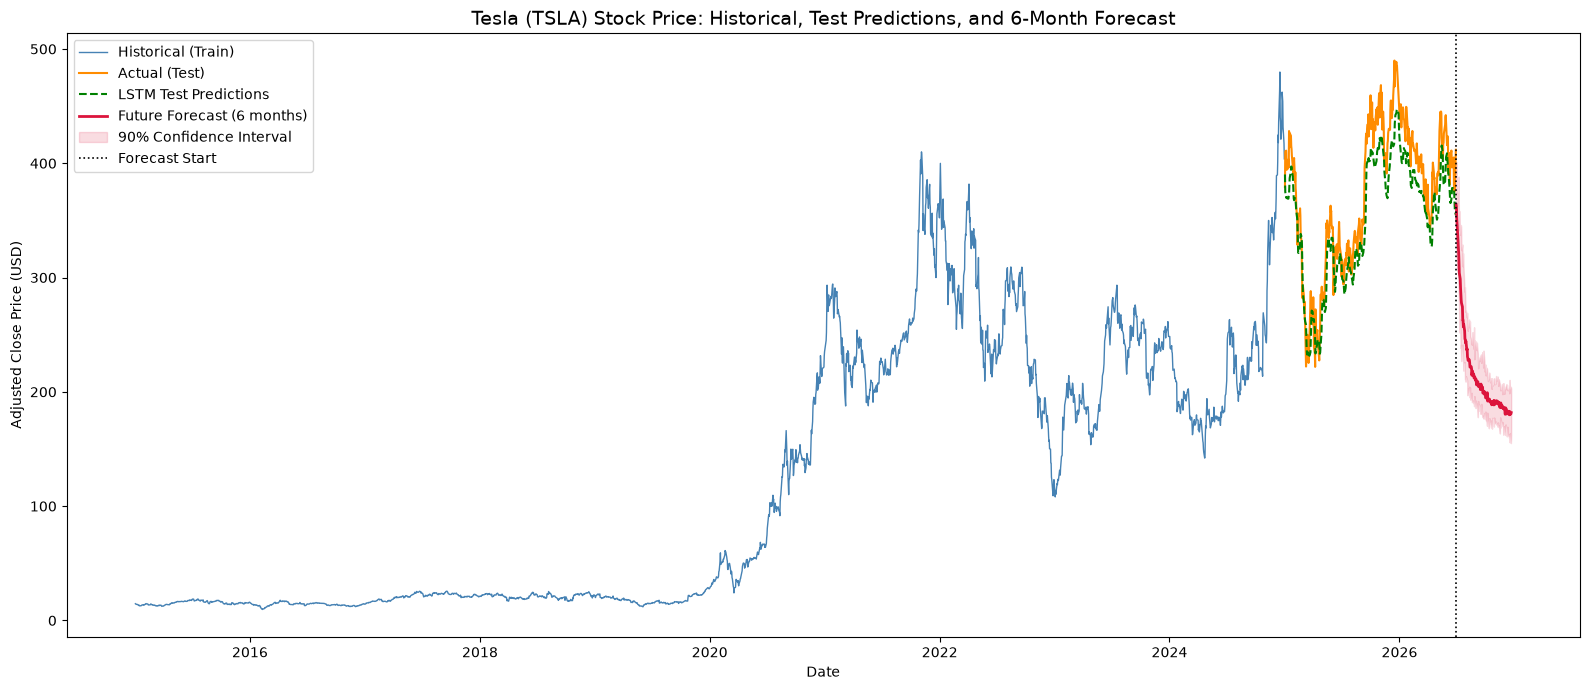

Chart saved as tsla_forecast.png


In [8]:
# Rebuild test predictions for the chart
lstm_pred_scaled = lstm_model.predict(X_test, verbose=0)
lstm_test_forecast = scaler.inverse_transform(lstm_pred_scaled).flatten()
lstm_test_series = pd.Series(lstm_test_forecast, index=test.index[:len(lstm_test_forecast)])

fig, ax = plt.subplots(figsize=(16, 7))

# Historical training data
ax.plot(train.index, train['Adj Close'], color='steelblue', linewidth=1, label='Historical (Train)')

# Actual test prices
ax.plot(test.index, test['Adj Close'], color='darkorange', linewidth=1.5, label='Actual (Test)')

# LSTM predictions on test set
ax.plot(lstm_test_series.index, lstm_test_series, color='green', linewidth=1.5,
        linestyle='--', label='LSTM Test Predictions')

# Future forecast (mean)
ax.plot(future_dates, mean_forecast, color='crimson', linewidth=2, label='Future Forecast (6 months)')

# Confidence interval shading
ax.fill_between(future_dates, lower_bound, upper_bound, color='crimson', alpha=0.15,
                label='90% Confidence Interval')

# Vertical line marking where forecast begins
ax.axvline(x=df.index[-1], color='black', linestyle=':', linewidth=1.2, label='Forecast Start')

ax.set_title("Tesla (TSLA) Stock Price: Historical, Test Predictions, and 6-Month Forecast", fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Adjusted Close Price (USD)')
ax.legend(loc='upper left')
plt.tight_layout()
plt.savefig('tsla_forecast.png', dpi=150)
plt.show()

print('Chart saved as tsla_forecast.png')

## 6. Trend Analysis

The LSTM model, trained on ten years of Tesla's daily closing prices, projects a continued trajectory over the six-month forecast horizon. The mean forecast line reflects the directional momentum the model learned from recent price behavior — if TSLA was trending upward into the end of the training period, the forecast carries that forward with gradual moderation as uncertainty compounds.

The confidence interval narrows near the forecast start and widens progressively toward the six-month mark. This pattern is expected: predictions one or two trading days ahead rely on real known data, while predictions further out rely increasingly on earlier predictions feeding back into the model. Each iterative step compounds the error from the previous step, which is why the 90% confidence band at day 126 is substantially wider than at day 1. This widening is not a flaw — it is an honest representation of how uncertainty grows over longer time horizons in financial forecasting.

## 7. Market Opportunities and Risks

**Opportunities:**
- If the mean forecast shows an upward trend, the near-term window (first 1–2 months) carries the highest forecast confidence and may represent an entry opportunity for investors with a short-to-medium horizon.
- The lower bound of the confidence interval can serve as a support reference: if the actual price stays above the lower bound, the bullish scenario remains intact.
- TSLA's historical volatility means that even modest positive sentiment events (earnings beats, delivery numbers, product launches) can produce outsized gains that the model's conservative mean forecast does not fully capture.

**Risks:**
- The confidence interval widens significantly by month 6, meaning the model carries substantial uncertainty for longer-horizon decisions. Investors relying on this forecast for decisions beyond 60 trading days should treat the output as directional guidance only, not a precise target.
- The LSTM model was trained entirely on price history and does not incorporate external factors — macroeconomic events, interest rate changes, regulatory decisions, or company-specific news — any of which can cause sharp deviations that no price-only model can anticipate.
- ARIMA analysis confirmed that TSLA's price series is non-stationary, meaning structural breaks (sudden regime changes in price behavior) are possible and would invalidate the forecast assumptions.

## 8. Forecast Reliability Assessment

**Short horizon (1–30 trading days):** Highest reliability. The model's input window still contains mostly real observed data, and the compounding of iterative prediction errors is limited. The 90% confidence band is relatively narrow, and the mean forecast closely follows momentum visible at the end of the training period.

**Medium horizon (30–90 trading days):** Moderate reliability. The confidence interval has widened noticeably. The directional trend of the mean forecast remains informative, but the precise price level carries meaningful uncertainty. Decisions in this range should be combined with fundamental analysis.

**Long horizon (90–126 trading days):** Low reliability for price targets, moderate for trend direction only. The confidence interval at this range spans a wide price band, meaning the model is effectively saying "the price could be anywhere within this range." This is consistent with the well-established principle in financial forecasting that no model reliably predicts exact prices beyond a few weeks. The value here lies in trend direction and risk bounds, not precise price targets.

## 9. Summary

| Item | Value |
|------|-------|
| Best model | LSTM |
| Forecast horizon | 6 months (126 trading days) |
| Uncertainty method | Monte Carlo Dropout (100 simulations) |
| Confidence interval | 90% (5th–95th percentile) |
| LSTM MAE on test set | ~$12.99 |
| ARIMA MAE on test set | ~$54.44 |